In [26]:

import numpy as np
import matplotlib.pyplot as plt


## 1

In [ ]:
def gen_huff_table(simbolos, prob):
    nos = []
    # dicionario
    tabela = {s: "" for s in simbolos}
    
    
    for i in range(len(simbolos)):
        s = simbolos[i]   
        f = prob[i]  
        if f > 0:
            # Guardamos: [frequência, lista_de_símbolos]
            nos.append([f, [s]])
    
    while len(nos) > 1:
        #  Ordenar para encontrar os dois mais pequenos
        nos.sort(key=lambda x: x[0])
        
        #  Retirar os dois menos prováveis
        no1 = nos.pop(0)
        no2 = nos.pop(0)
        
        
        # Quem está no grupo 1 ganha um '0' no início do código
        for s in no1[1]:
            tabela[s] = '0' + tabela[s]
            
        # Quem está no grupo 2 ganha um '1' no início do código
        for s in no2[1]:
            tabela[s] = '1' + tabela[s]
            
        # Criar o novo nó (pai) e colocar de volta na lista[cite: 2]
        novo_no = [no1[0] + no2[0], no1[1] + no2[1]]
        nos.append(novo_no)
    
    # Retornamos apenas os símbolos que tinham probabilidade > 0
    return {s: c for s, c in tabela.items() if c != ""}

In [ ]:

simb = ['a', 'b', 'c', 'd', 'e']
prob = [0.25, 0.25, 0.2, 0.15, 0.15]


resultado = gen_huff_table(simb, prob)


print(resultado)

{'a': '01', 'b': '10', 'c': '00', 'd': '110', 'e': '111'}


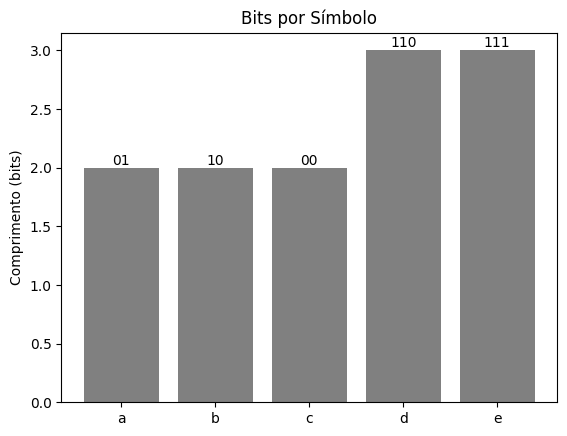

In [ ]:

nomes = list(resultado.keys())
bits = [len(v) for v in resultado.values()]


plt.bar(nomes, bits, color='gray')
plt.title('Bits por Símbolo')
plt.ylabel('Comprimento (bits)')


for i in range(len(nomes)):
    plt.text(i, bits[i], list(resultado.values())[i], ha='center', va='bottom')

plt.show()

## 2

In [ ]:
def encode_huff(mensagem, tabela):
  
    sequencia_bits = ""
    
    # Percorrer cada símbolo na mensagem original
    for simbolo in mensagem:
        # buscar o código binário correspondente na tabela[cite: 1, 2]
        codigo = tabela[simbolo]
        
        
        sequencia_bits += codigo
        
    return sequencia_bits

In [31]:
mensagem_teste = ['a', 'b', 'a', 'c', 'd', 'e']
bits_codificados = encode_huff(mensagem_teste, resultado)

print(f"Mensagem Original: {mensagem_teste}")
print(f"Mensagem Codificada (bits): {bits_codificados}")

Mensagem Original: ['a', 'b', 'a', 'c', 'd', 'e']
Mensagem Codificada (bits): 01100100110111


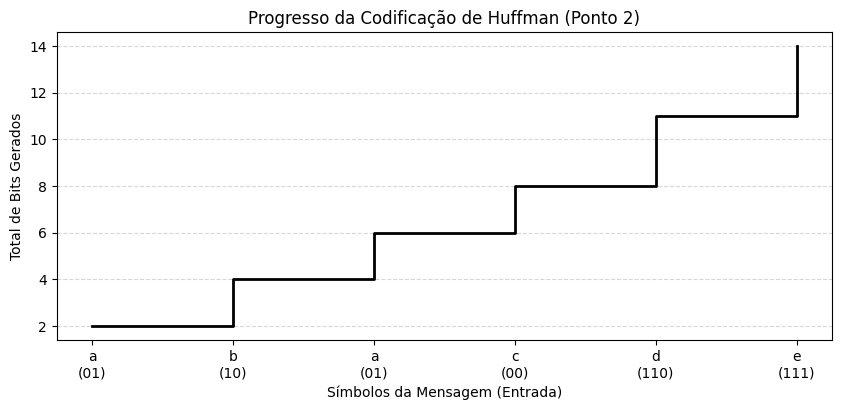

In [ ]:
acumulado = ""
bits_por_passo = []
labels = []

for s in mensagem_teste:
    codigo = resultado[s]
    acumulado += codigo
    bits_por_passo.append(len(acumulado))
    labels.append(f"{s}\n({codigo})")


plt.figure(figsize=(10, 4))
plt.step(range(len(mensagem_teste)), bits_por_passo, where='post', color='black', linewidth=2)
plt.xticks(range(len(mensagem_teste)), labels)


plt.title("Progresso da Codificação de Huffman (Ponto 2)")
plt.xlabel("Símbolos da Mensagem (Entrada)")
plt.ylabel("Total de Bits Gerados")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## 3

In [ ]:
def decode_huff(bits, tabela):
    
    tabela_inversa = {v: k for k, v in tabela.items()}
    
    mensagem_descodificada = []
    bit_buffer = ""
    

    for bit in bits:
        bit_buffer += bit 
        if bit_buffer in tabela_inversa:
            simbolo = tabela_inversa[bit_buffer]
            mensagem_descodificada.append(simbolo)
            bit_buffer = "" # Limpar o buffer para o próximo símbolo
            
    return mensagem_descodificada

In [ ]:
bits_gerados = encode_huff(simb, resultado) 
mensagem_final = decode_huff(bits_gerados, resultado)


if list(simb) == mensagem_final:
    print("Sucesso: A mensagem descodificada é igual à original!")
else:
    print("Erro: As mensagens são diferentes.")

Sucesso: A mensagem descodificada é igual à original!


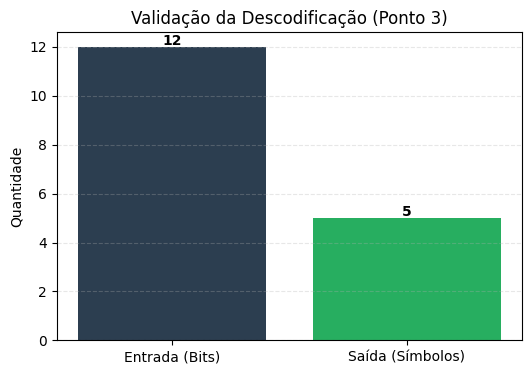

In [ ]:
tamanhos = [len(bits_gerados), len(mensagem_final)]
labels = ['Entrada (Bits)', 'Saída (Símbolos)']


plt.figure(figsize=(6, 4))
plt.bar(labels, tamanhos, color=['#2c3e50', '#27ae60'])


for i, v in enumerate(tamanhos):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.title('Validação da Descodificação (Ponto 3)')
plt.ylabel('Quantidade')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## 4

In [ ]:
def encode_table(tabela):

    bits_tabela = ""
    
    for simbolo, codigo in tabela.items():

        if isinstance(simbolo, str) and not simbolo.isdigit():
            valor_numerico = ord(simbolo)
        else:
            valor_numerico = int(simbolo)
            
        # Converter para 8 bits fixos
        simbolo_bin = format(valor_numerico, '08b')
        
      
        tamanho_codigo = format(len(codigo), '05b')
        
   
        bits_tabela += simbolo_bin + tamanho_codigo + codigo
        
    return bits_tabela

In [ ]:

tabela_huff = gen_huff_table(simb, prob)


bits_mensagem = encode_huff(simb, tabela_huff)


bits_tabela = encode_table(tabela_huff)


sequencia_final = bits_tabela + bits_mensagem

print(f"Bits da tabela: {len(bits_tabela)}")
print(f"Bits da mensagem: {len(bits_mensagem)}")
print(f"Total a transmitir: {len(sequencia_final)}")

Bits da tabela: 77
Bits da mensagem: 12
Total a transmitir: 89


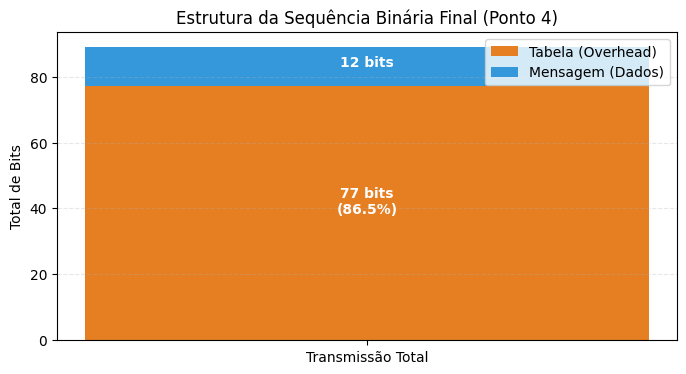

In [ ]:
categorias = ['Transmissão Total']
largura_tabela = [len(bits_tabela)]
largura_mensagem = [len(bits_mensagem)]


plt.figure(figsize=(8, 4))
p1 = plt.bar(categorias, largura_tabela, color='#e67e22', label='Tabela (Overhead)')
p2 = plt.bar(categorias, largura_mensagem, bottom=largura_tabela, color='#3498db', label='Mensagem (Dados)')


total = len(sequencia_final)
pct_tabela = (len(bits_tabela) / total) * 100

plt.text(0, len(bits_tabela)/2, f"{len(bits_tabela)} bits\n({pct_tabela:.1f}%)", 
         ha='center', color='white', fontweight='bold')
plt.text(0, len(bits_tabela) + len(bits_mensagem)/2, f"{len(bits_mensagem)} bits", 
         ha='center', color='white', fontweight='bold')


plt.title('Estrutura da Sequência Binária Final (Ponto 4)')
plt.ylabel('Total de Bits')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()